In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pickle as p
import itertools

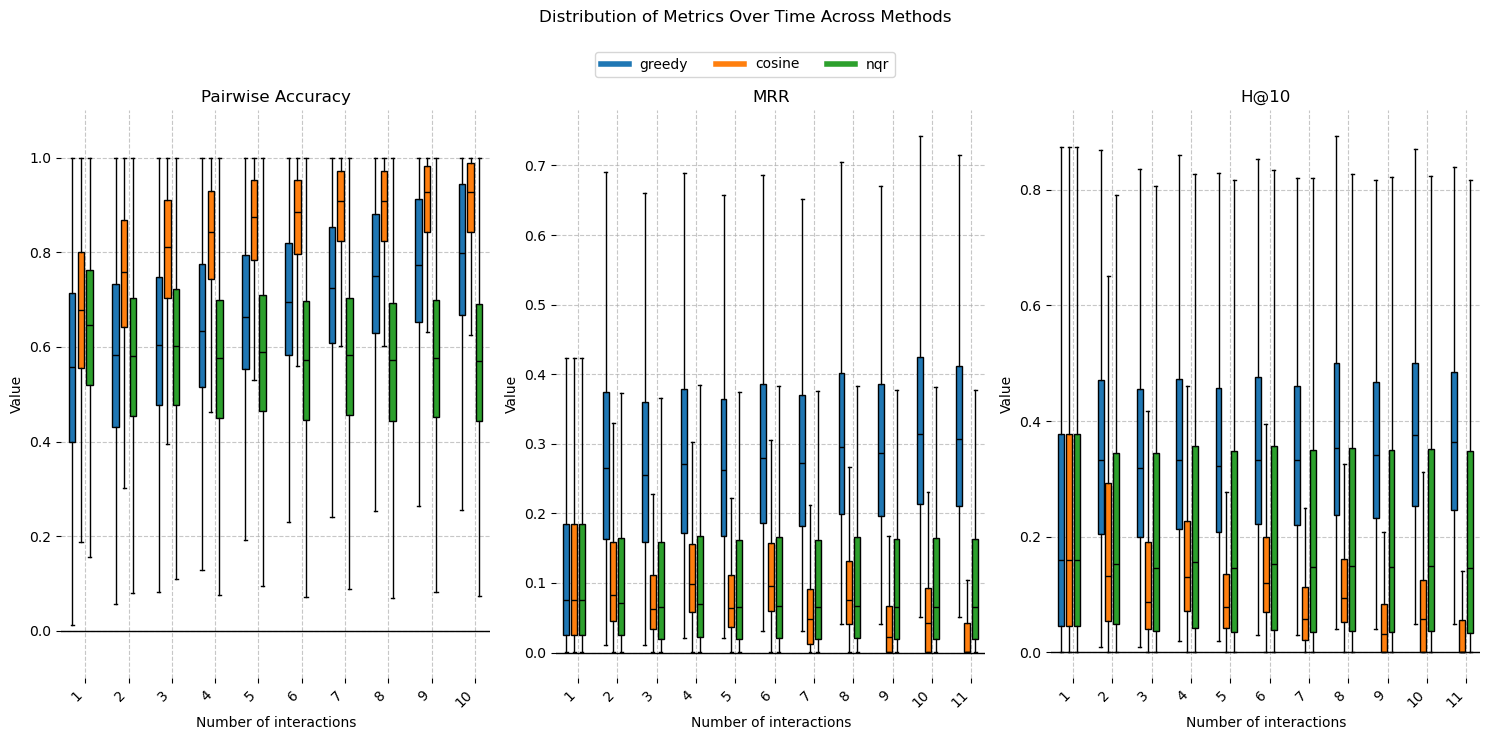

In [3]:
def plot_metrics_comparison(file_paths, method_names):
    """
    Plots boxplots of metrics over time for multiple methods.
    :param file_paths: List of file paths containing metrics.
    :param method_names: List of method names corresponding to each file.
    """
    assert len(file_paths) == len(method_names), "Number of file paths must match number of method names."

    colors = [f"C{i}" for i in range(len(file_paths))]  # Define distinct colors
    num_methods = len(file_paths)
    metrics_all_methods = []

    for file_path in file_paths:
        with open(file_path, "rb") as f:
            total_metrics_over_t_10 = p.load(f)

        # Extract metrics
        mrr_hard = np.array(total_metrics_over_t_10['mrr_hard'])
        hits_at_10 = np.array(total_metrics_over_t_10['hits@10_hard'])
        pairwise_acc = np.array(total_metrics_over_t_10['pairwise_accuracy'])

        metrics_all_methods.append([pairwise_acc, mrr_hard, hits_at_10])

    # Create subplots for boxplots
    titles = ['Pairwise Accuracy', 'MRR', 'H@10']#, '$\Delta$Hits@10']
    fig, axes = plt.subplots(1, len(titles), figsize=(15, 7))  # Increase figure size for better spacing

    # Plot metrics
    for ax, title, metric_idx in zip(axes, titles, range(len(titles))):
        for method_idx, (metrics, method_name, color) in enumerate(zip(metrics_all_methods, method_names, itertools.cycle(colors))):
            metric = metrics[metric_idx]
            num_timesteps = metric.shape[1]

            time_steps = np.arange(1, num_timesteps + 1) * 2.0  # Increase spacing between interaction points

            positions = time_steps + (method_idx - num_methods / 2) * 0.4  # Increase offset for better visibility
            box = ax.boxplot(metric, positions=positions, widths=0.3, patch_artist=True, medianprops={'color': 'black'}, showfliers=False)

            for patch in box['boxes']:
                patch.set_facecolor(color)  # Set different colors for each method

            # ax.plot(time_steps, metric.mean(axis=0))

        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel('Number of interactions')
        ax.set_ylabel('Value')
        ax.set_xticks(time_steps)
        ax.set_xticklabels(range(1, num_timesteps + 1), rotation=45, ha='right')  # Prevent overlapping labels

        if title == 'Pairwise Accuracy':
            ax.set_ylim(-0.1, 1.1)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        ax.axhline(0, color='black', linewidth=1)

    # Add legend with correct colors
    legend_patches = [plt.Line2D([0], [0], color=color, lw=4) for color in colors[:num_methods]]
    fig.legend(legend_patches, method_names, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=len(method_names))

    fig.suptitle('Distribution of Metrics Over Time Across Methods', y=1.05)
    plt.tight_layout()
    # plt.show()
    # plt.savefig("neg.png")

plot_metrics_comparison([
    # "../results/fb15k237-betae_10_0.0002_random_test_mixed_1745591959/metrics_over_time_test_mixed.pkl",
    "../results/fb15k237-betae_10_0.0002_greedy_test_mixed_1745998797/metrics_over_time_test_mixed.pkl",
    "../results/fb15k237-betae_10_0.0002_cosine_0.1_0.9_test_mixed_1746011235/metrics_over_time_test_mixed.pkl",
    "../results/fb15k237-betae_10_0.0002_nqr_0.001_test_mixed_1746020972/metrics_over_time_test_mixed.pkl"
],
    [
        # "random",
        "greedy",
        "cosine",
        "nqr"
    ])

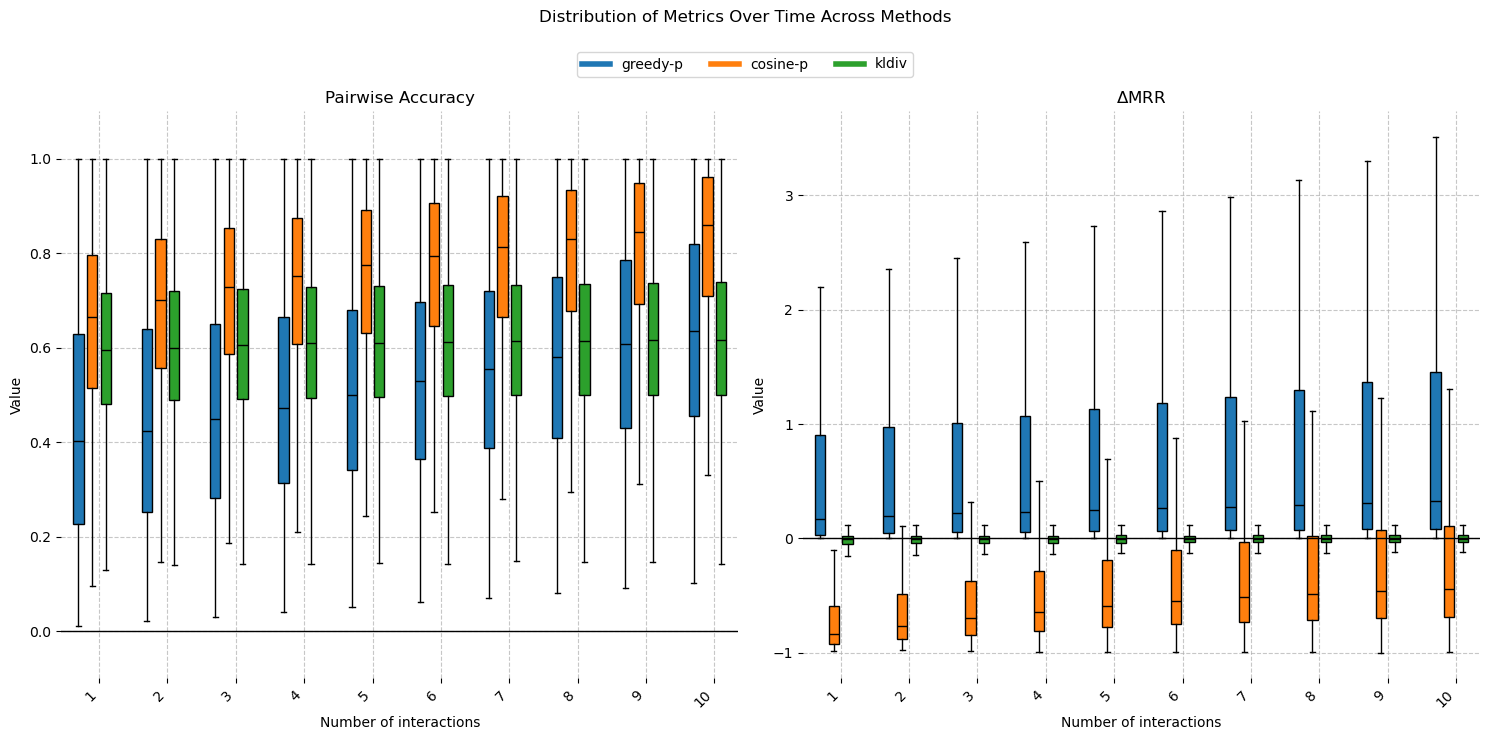

In [7]:
//plot_metrics_comparison([
    "/home/daniel/projects/quack/results/fb15k_10_0.001_greedy_test_positive_1738676398/metrics_over_time_test_positive.pkl",
    "../results/fb15k_10_0.001_cosine_0.1_test_positive_1738673171/metrics_over_time_test_positive.pkl",
    # "../results/fb15k_10_0.001_ltr_0.0001_positive_1739493134/metrics_over_time_test_positive.pkl",
    "../results/fb15k_10_0.001_ltr_0.001_test_positive_1740656535/metrics_over_time_test_positive.pkl",
    # "../results/fb15k_10_0.001_ltr_0.0001_positive_1739562177/metrics_over_time_test_positive.pkl"
],
    [
        "greedy-p",
        "cosine-p",
        "kldiv",
        # "learnedcos"
    ])

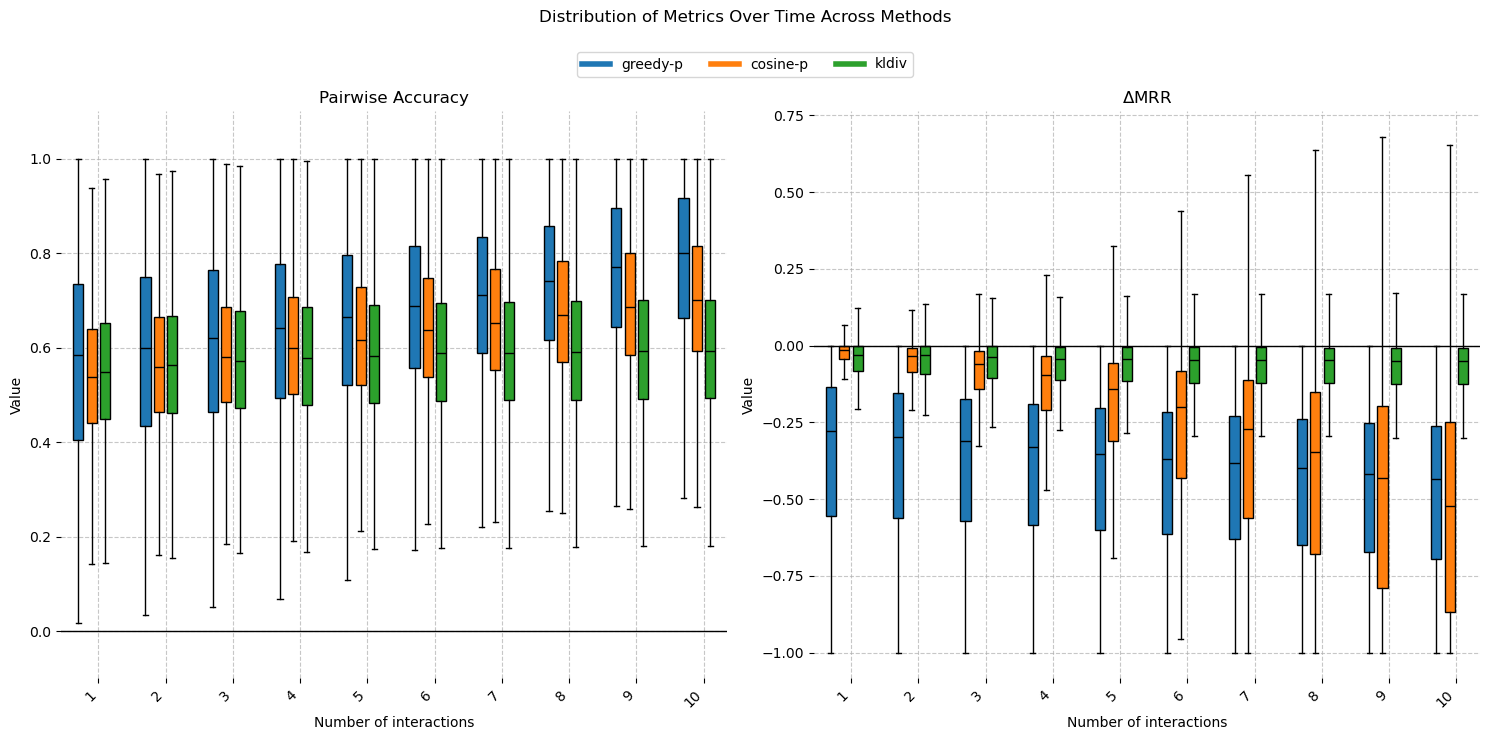

In [9]:
plot_metrics_comparison([
    "/home/daniel/projects/quack/results/fb15k_10_0.001_greedy_test_negative_1738674178/metrics_over_time_test_negative.pkl",
    "../results/fb15k_10_0.001_cosine_0.9_test_negative_1738673179/metrics_over_time_test_negative.pkl",
    "../results/fb15k_10_0.001_ltr_0.001_test_negative_1740732882/metrics_over_time_test_negative.pkl",
    # "../results/fb15k_10_0.001_ltr_0.0001_positive_1739493134/metrics_over_time_test_negative.pkl",
    # "../results/fb15k_10_0.001_ltr_0.0001_positive_1739562177/metrics_over_time_test_negative.pkl"
    ],
    [
        "greedy-p",
        "cosine-p",
        "kldiv",
        # "learnedcos"
    ])